# 🔥 Climate-Induced Disasters: Fire & Flood Mapping
## Arab 813 Hackathon — Planet Tanager Hyperspectral Explorer

This notebook uses **Planet's Tanager hyperspectral satellite** to analyse **wildfire burn scars and disaster-affected land** — applications of direct relevance to disaster response and climate resilience.

---

## What You Will Learn

- How fire and flood damage appears in hyperspectral imagery
- How to access both the `fire` and `disasters` STAC collections
- How to compute burn scar, fire severity, and flood indices:
  - **NBR** — Normalized Burn Ratio (active fire / burn scar)
  - **dNBR** — Delta NBR (fire severity when two dates available)
  - **BAIM** — Burn Area Index (Modified)
  - **NDWI** — water / flood detection

---

## How Does Tanager See Fire Damage?

Fire dramatically changes land surface reflectance:
- **Pre-fire:** green vegetation with high NIR (~800 nm) and low SWIR (~2,200 nm)
- **Post-fire:** charred surface with low NIR and high SWIR → the NBR drops sharply
- **Active fire:** extreme thermal radiance in SWIR that saturates the detector

The **NBR** (`(NIR - SWIR) / (NIR + SWIR)`) exploits this contrast and is the standard fire severity index used by forest agencies worldwide.

---

## Relevant STAC Collections

- **Fire:** `https://www.planet.com/data/stac/tanager-core-imagery/fire/collection.json`
- **Disasters:** `https://www.planet.com/data/stac/browser/disasters/collection.json`


In [1]:
%pip install pystac-client planetary-computer stackstac rasterio xarray matplotlib geopandas leafmap ipywidgets rioxarray h5py requests

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
# Reset leafmap titiler endpoint to the public instance.
# This prevents errors if Planetary Computer cells ran earlier in the session.
os.environ["TITILER_ENDPOINT"] = "https://titiler.xyz"

## Step 1 – Browse & Load the Fire Collection

We first read the collection index to see all available scenes, then pick one.


In [3]:
import requests

COLLECTION = "fire"
col_url = f"https://www.planet.com/data/stac/tanager-core-imagery/{COLLECTION}/collection.json"
col = requests.get(col_url, timeout=60).json()

item_links = [l for l in col.get("links", []) if l.get("rel") == "item"]
print(f"Found {len(item_links)} scenes in '{COLLECTION}'")
for lnk in item_links[:15]:
    iid = lnk["href"].split("/")[-1].replace(".json","")
    print(" ", iid)

/Users/vincentmarkiet/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 11 scenes in 'fire'
  20241215_185916_33_4001
  20250123_185507_64_4001
  20250123_185518_92_4001
  20250407_192235_24_4001
  20250407_192229_16_4001
  20250920_193207_61_4001
  20250726_192343_21_4001
  20250726_192422_87_4001
  20250724_190927_83_4001
  20250902_190116_02_4001
  20250902_190121_86_4001


In [4]:
# Load the first available fire scene
item_url = item_links[0]["href"]
item = requests.get(item_url, timeout=60).json()
print("Scene ID:", item["id"])
print("Date    :", item["properties"]["datetime"])
print("Bbox    :", item["bbox"])

Scene ID: 20241215_185916_33_4001
Date    : 2024-12-15T18:59:16.349662Z
Bbox    : [-118.84705590250647, 33.91950767743557, -118.59241930222035, 34.10982552617667]


## Step 2 – Thumbnail & Metadata


In [5]:
from IPython.display import Image
print("Scene ID:", item["id"])
print("Date    :", item["properties"]["datetime"])
print("Bbox    :", item["bbox"])
Image(url=item["assets"]["thumbnail"]["href"])

Scene ID: 20241215_185916_33_4001
Date    : 2024-12-15T18:59:16.349662Z
Bbox    : [-118.84705590250647, 33.91950767743557, -118.59241930222035, 34.10982552617667]


In [6]:
import json
print(json.dumps(item["properties"], indent=2))

{
  "cloud_percent": 0,
  "collection_mode": "maximum_sensitivity",
  "constellation": "Tanager",
  "datetime": "2024-12-15T18:59:16.349662Z",
  "description": "All data products from Tanager-1 for 20241215_185916_33_4001 near Malibu, Los Angeles County, California, United States",
  "gsd": 37.45,
  "instruments": [
    "4001"
  ],
  "license": "CC-BY-4.0",
  "light_haze_percent": 0,
  "location_description": "Malibu, Los Angeles County, California, United States",
  "notes": null,
  "platform": "Planet",
  "plume_provider_ids": null,
  "quality_category": "test",
  "title": "TanagerScene 20241215_185916_33_4001 Core Imagery",
  "view:azimuth": 244.2,
  "view:off_nadir": 6.8,
  "view:sun_azimuth": 166.3,
  "view:sun_elevation": 31.4
}


## Step 3 – Interactive Map


In [7]:
import leafmap, geopandas as gpd
from shapely.geometry import box

m = leafmap.Map(zoom=8)
ib = item["bbox"]
m.fit_bounds([[ib[1], ib[0]], [ib[3], ib[2]]])

# Scene footprint
gdf = gpd.GeoDataFrame({"geometry": [box(*ib)]}, crs="EPSG:4326")
m.add_gdf(gdf, layer_name="Scene footprint", style={"color":"yellow","fillOpacity":0})

# Visual COG overlay
for vk in ["ortho_visual", "visual", "rendered_preview"]:
    if vk in item.get("assets", {}):
        m.add_cog_layer(item["assets"][vk]["href"],
                        name=item["id"]+" (visual)",
                        titiler_endpoint="https://titiler.xyz")
        break

m

Map(center=[-118.71987173369487, 34.01451016263488], controls=(ZoomControl(options=['position', 'zoom_in_text'…

## Step 4 – Download Surface Reflectance


In [8]:
import os, requests

sr_key = "ortho_sr_hdf5" if "ortho_sr_hdf5" in item["assets"] else "basic_sr_hdf5"
sr_url = item["assets"][sr_key]["href"]
print("Using SR asset:", sr_key)
print("URL:", sr_url)

local_path = os.path.basename(sr_url)
if not os.path.exists(local_path):
    print("Downloading… (may take a few minutes)")
    with requests.get(sr_url, stream=True) as r:
        r.raise_for_status()
        with open(local_path, "wb") as fout:
            for chunk in r.iter_content(chunk_size=1024*1024):
                if chunk:
                    fout.write(chunk)
    print("Saved to:", local_path)
else:
    print("Already downloaded:", local_path)

Using SR asset: ortho_sr_hdf5
URL: https://storage.googleapis.com/open-cogs/planet-stac/tanager1-release2-core-imagery/ortho_sr_hdf5/20241215_185916_33_4001_ortho_sr_hdf5.h5
Downloading… (may take a few minutes)
Saved to: 20241215_185916_33_4001_ortho_sr_hdf5.h5


## Step 5 – Quality Masks


In [9]:
import h5py, numpy as np

root = "HDFEOS/GRIDS/HYP/Data Fields"
with h5py.File(local_path, "r") as f:
    cloud  = f[f"{root}/beta_cloud_mask"][:]
    nodata = f[f"{root}/nodata_pixels"][:]
    cirrus = f[f"{root}/beta_cirrus_mask"][:]

valid = (nodata == 0) & (cloud == 0) & (cirrus == 0)
print(f"Valid pixels: {valid.mean()*100:.1f}%")
print(f"Cloud cover:  {(cloud!=0).mean()*100:.1f}%")

Valid pixels: 71.4%
Cloud cover:  0.0%


## Step 6 – Extract Spectral Wavelengths


In [10]:
# Extract spectral wavelengths from STAC metadata.
# The key is "bands" and wavelengths are in micrometers under "eo:center_wavelength".
bands_meta = item["assets"][sr_key].get("bands", [])
spectral_bands = [b for b in bands_meta if "eo:center_wavelength" in b]
wavelengths_um = np.array([b["eo:center_wavelength"] for b in spectral_bands], dtype=float)
wavelengths_nm = wavelengths_um * 1000.0   # micrometers -> nanometers

print("Number of spectral bands:", len(wavelengths_nm))
print("First 10 wavelengths (nm):", np.round(wavelengths_nm[:10], 2))
print("Last  10 wavelengths (nm):", np.round(wavelengths_nm[-10:], 2))

Number of spectral bands: 426
First 10 wavelengths (nm): [376.44 381.41 386.38 391.35 396.32 401.29 406.26 411.23 416.21 421.18]
Last  10 wavelengths (nm): [2454.39 2459.35 2464.31 2469.26 2474.22 2479.18 2484.13 2489.09 2494.04
 2499.  ]


## Step 7 – Select Key Wavelengths for Fire/Disaster Mapping


In [11]:
import numpy as np
def pick_band(target_nm):
    idx = int(np.argmin(np.abs(wavelengths_nm - target_nm)))
    print(f"  Target {target_nm} nm → band {idx} ({wavelengths_nm[idx]:.1f} nm)")
    return idx, wavelengths_nm[idx]

print("Selecting bands:")
idx_green, _ = pick_band(560)
idx_red,   _ = pick_band(665)
idx_nir,   _ = pick_band(860)
idx_swir1, _ = pick_band(1640)
idx_swir2, _ = pick_band(2200)

Selecting bands:
  Target 560 nm → band 37 (560.8 nm)
  Target 665 nm → band 58 (665.9 nm)
  Target 860 nm → band 97 (861.3 nm)
  Target 1640 nm → band 252 (1637.7 nm)
  Target 2200 nm → band 365 (2201.2 nm)


## Step 8 – Load Bands


In [12]:
import h5py

root = "HDFEOS/GRIDS/HYP/Data Fields"

with h5py.File(local_path, "r") as f:
    sr = f[f"{root}/surface_reflectance"]
    R_green = sr[idx_green, :, :].astype("float32")
    R_red   = sr[idx_red,   :, :].astype("float32")
    R_nir   = sr[idx_nir,   :, :].astype("float32")
    R_swir1 = sr[idx_swir1, :, :].astype("float32")
    R_swir2 = sr[idx_swir2, :, :].astype("float32")

for arr in [R_green, R_red, R_nir, R_swir1, R_swir2]:
    arr[~valid] = np.nan
    arr[arr < 0] = np.nan
print("Bands loaded:", R_red.shape)

Bands loaded: (713, 791)


## Step 9 – Compute Fire & Disaster Indices

### NBR — Normalized Burn Ratio
**Formula:** `(NIR - SWIR₂₂₀₀) / (NIR + SWIR₂₂₀₀)`

- Pre-fire healthy vegetation: NBR ≈ +0.3 to +0.7
- Post-fire burn scar: NBR ≈ −0.5 to +0.1
- Fire severity = pre-fire NBR − post-fire NBR (dNBR)


In [13]:
eps = 1e-6
NBR  = (R_nir - R_swir2) / (R_nir + R_swir2 + eps)

### BAIM — Burn Area Index Modified
**Formula:** `1 / ((0.05 - ρNIR)² + (0.2 - ρSWIR)²)`

Designed to maximize sensitivity to burned areas in SWIR. High BAIM → recently burned.


In [14]:
BAIM = 1.0 / ((0.05 - R_nir)**2 + (0.2 - R_swir2)**2 + eps)
BAIM = np.clip(BAIM, 0, 500)  # cap extreme values for visualization

### NDWI — Flood Water Detection
**Formula:** `(Green - NIR) / (Green + NIR)`

Positive NDWI → open water (flood inundation, river overflow).


In [15]:
NDWI = (R_green - R_nir) / (R_green + R_nir + eps)

### NDVI — Vegetation (for context)


In [16]:
NDVI = (R_nir - R_red) / (R_nir + R_red + eps)

## Step 10 – Visualize


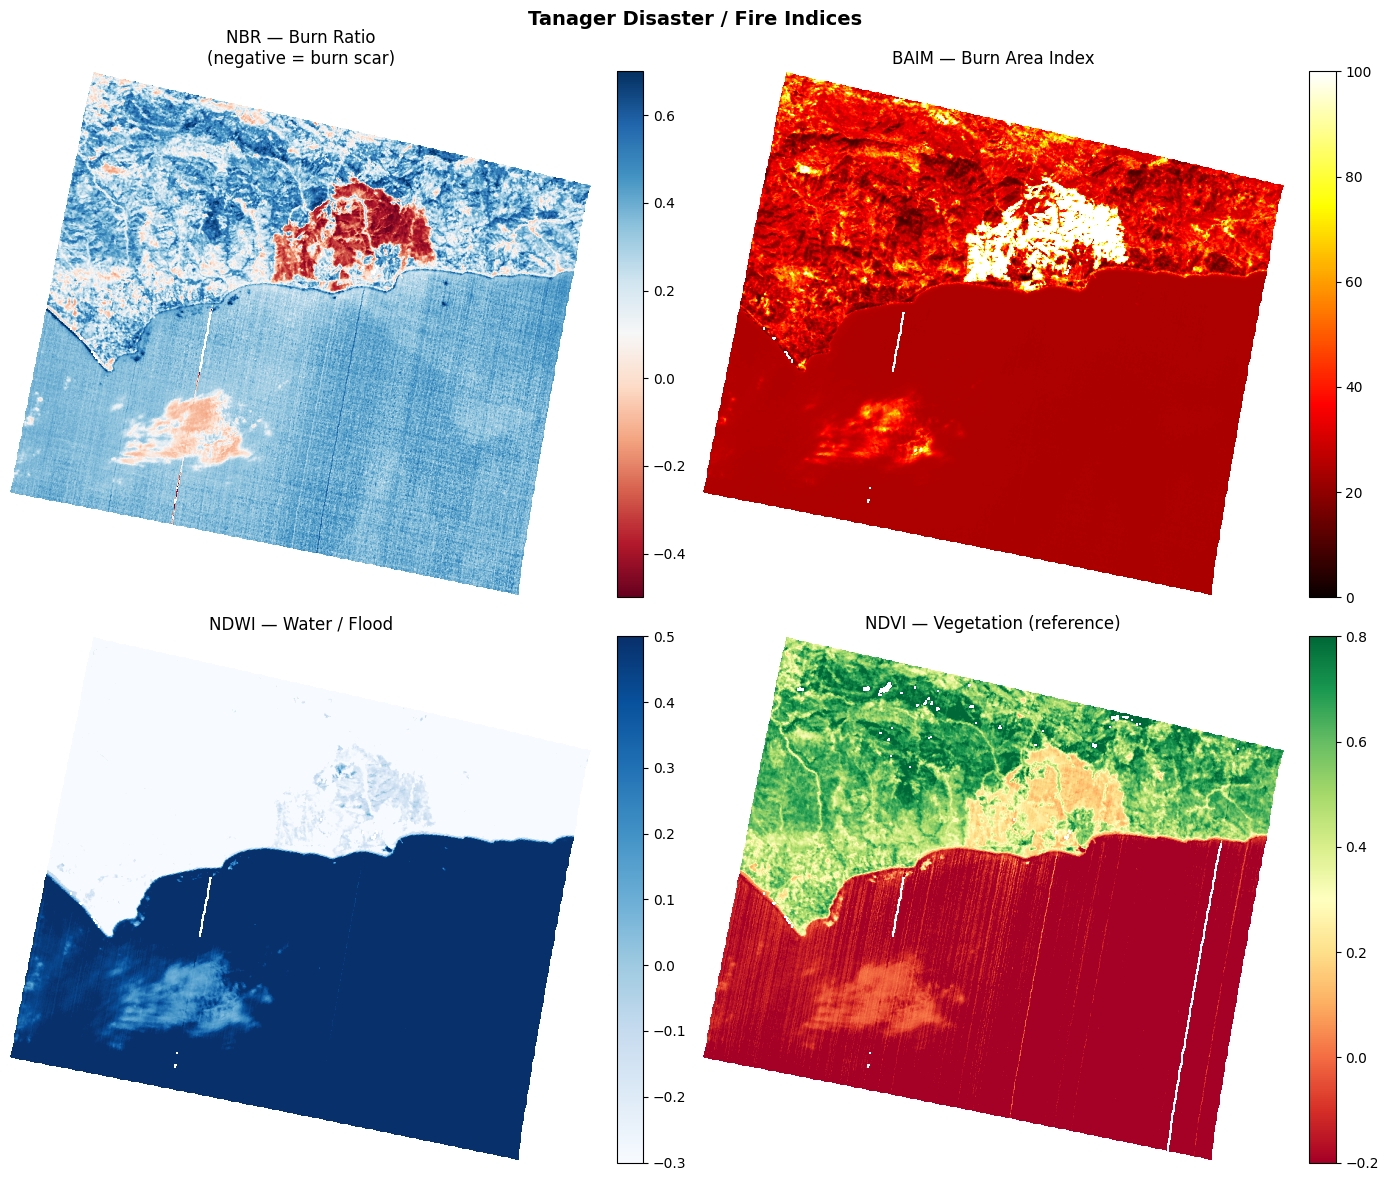

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

im1 = axes[0,0].imshow(NBR,  cmap="RdBu",     vmin=-0.5, vmax=0.7)
axes[0,0].set_title("NBR — Burn Ratio\n(negative = burn scar)"); axes[0,0].axis("off")
plt.colorbar(im1, ax=axes[0,0], fraction=0.046, pad=0.04)

im2 = axes[0,1].imshow(BAIM, cmap="hot",      vmin=0,    vmax=100)
axes[0,1].set_title("BAIM — Burn Area Index"); axes[0,1].axis("off")
plt.colorbar(im2, ax=axes[0,1], fraction=0.046, pad=0.04)

im3 = axes[1,0].imshow(NDWI, cmap="Blues",    vmin=-0.3, vmax=0.5)
axes[1,0].set_title("NDWI — Water / Flood"); axes[1,0].axis("off")
plt.colorbar(im3, ax=axes[1,0], fraction=0.046, pad=0.04)

im4 = axes[1,1].imshow(NDVI, cmap="RdYlGn",   vmin=-0.2, vmax=0.8)
axes[1,1].set_title("NDVI — Vegetation (reference)"); axes[1,1].axis("off")
plt.colorbar(im4, ax=axes[1,1], fraction=0.046, pad=0.04)

plt.suptitle("Tanager Disaster / Fire Indices", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## Step 11 – Classify Burn Severity

We apply NBR thresholds from the UN/USGS burn severity classification scheme.


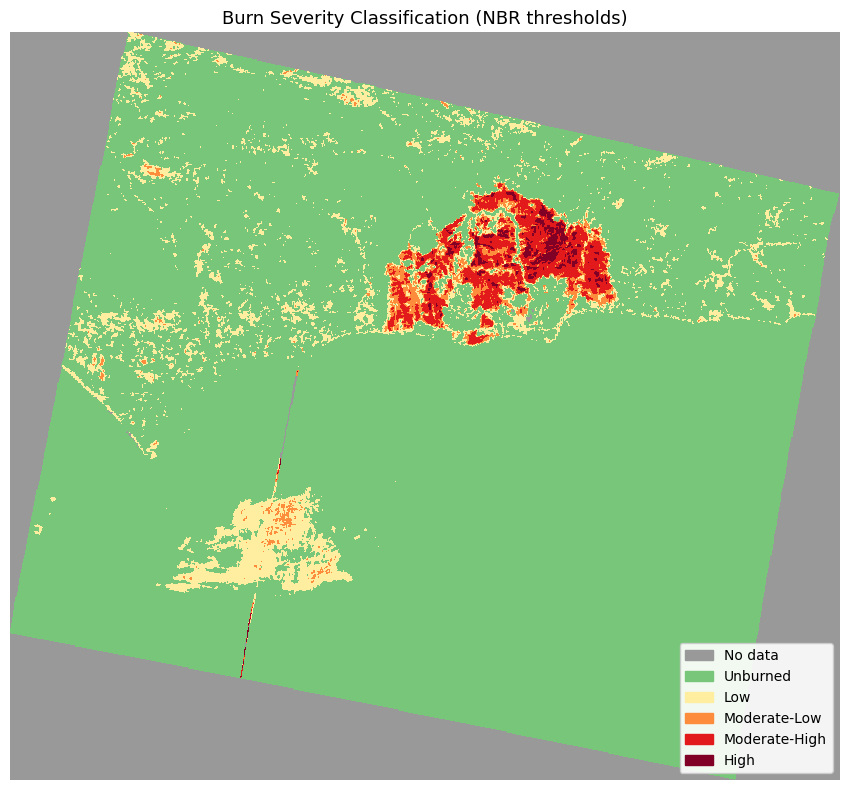

In [18]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

severity = np.full(NBR.shape, 0, dtype=np.uint8)
severity[NBR >= 0.1]                        = 1   # Unburned
severity[(NBR >= -0.1) & (NBR < 0.1)]      = 2   # Low severity
severity[(NBR >= -0.27) & (NBR < -0.1)]    = 3   # Moderate-low
severity[(NBR >= -0.44) & (NBR < -0.27)]   = 4   # Moderate-high
severity[NBR < -0.44]                       = 5   # High severity

cmap5 = ListedColormap(["#999999","#78C679","#FFEDA0","#FD8D3C","#E31A1C","#800026"])
labels5 = ["No data","Unburned","Low","Moderate-Low","Moderate-High","High"]
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(severity, cmap=cmap5, vmin=0, vmax=5)
ax.set_title("Burn Severity Classification (NBR thresholds)", fontsize=13)
ax.axis("off")
handles = [Patch(color=c, label=l) for c,l in zip(cmap5.colors, labels5)]
ax.legend(handles=handles, loc="lower right", framealpha=0.9)
plt.tight_layout(); plt.show()

## Step 12 – Mean Spectrum


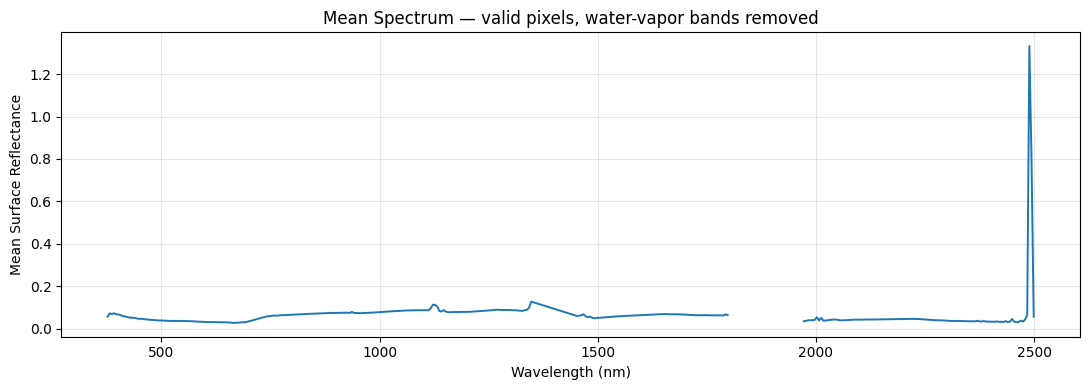

In [19]:
def is_water_vapor(wl):
    return (1350 <= wl <= 1450) or (1800 <= wl <= 1950)

stride = 8
with h5py.File(local_path, "r") as f:
    sr = f[f"{root}/surface_reflectance"]
    good_idx = [i for i, w in enumerate(wavelengths_nm) if not is_water_vapor(w)]
    cube = sr[good_idx, ::stride, ::stride].astype("float32")
    mask = valid[::stride, ::stride]
    cube[:, ~mask] = np.nan
    cube[cube < 0] = np.nan
    mean_spec = np.nanmean(cube, axis=(1,2))

import matplotlib.pyplot as plt
wls = [wavelengths_nm[i] for i in good_idx]
plt.figure(figsize=(11,4))
plt.plot(wls, mean_spec, lw=1.4)
plt.xlabel("Wavelength (nm)"); plt.ylabel("Mean Surface Reflectance")
plt.title("Mean Spectrum — valid pixels, water-vapor bands removed")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## 🚀 Hackathon Challenge Ideas

- **Burn scar area calculation** — count pixels in each severity class × pixel area (30m × 30m)
- **Disaster progression** — load pre- and post-disaster scenes to compute dNBR
- **Flood extent mapping** — threshold NDWI to map flood boundaries and compare to building footprints
- **Recovery monitoring** — how does NDVI change in the months after a fire?

> 📖 Created by: [LInkedin: Dr. Vincent Markiet - Space42](https://www.linkedin.com/in/vincentmarkiet/) 

> 📖 Data license: CC-BY-4.0 © Planet Labs PBC
